# Retraining sn2-matched-lorem under the fixed architecture (version 4)

Notebook `20` found that `LOREM.load_checkpoint` was silently dropping 47 trained
parameters to random initialization for any checkpoint saved before the
equivariant-message-passing / TensorDense-CG refactors (`metatrain` commits
`700c0b73`/`ce58eaae`) -- including the real `sn2-matched-lorem`/`sn2-matched-lorem-dipole`
checkpoints this whole notebook series relies on. That silent drop is now fixed
upstream (`experimental/lorem` branch, commits `9804dcbd`/`564664cb`):
`load_state_dict` is strict again, and `LOREM.__checkpoint_version__` was bumped to 4
with an explicit, unconditional refusal to upgrade any version-3 checkpoint (no
automatic weight migration is possible for genuinely new capacity). That fix makes
every local LOREM checkpoint -- including `sn2-matched-lorem` -- permanently
unloadable as a checkpoint from here on; only its already-exported `model.pt` remains
usable, for inference only.

**This notebook documents what came next**: retraining `sn2-matched-lorem` from its
original recipe (same data, same hypers, same 50 epochs, same seed) under the current,
version-4 architecture, to get a real, `strict=True`-loadable replacement -- not a
patched-over old one -- and checking that the retrain doesn't change the physics
picture notebook 20 built up (the ASE-vs-periodic gap, and engine-vs-engine
agreement).

## 1. The retrain

```
$ cd /home/boittier/data/sn2-matched-lorem-v4   # fresh dir, sn2.xyz symlinked in
$ mtt train /home/boittier/metawork/etc/sn2_zenodo/options/matched-budget/energy-forces-lorem.yaml
```

Same command the original `sn2-matched-lorem` was trained with (`options_restart.yaml`
in its own `outputs/` directory records it), just against the current, version-4
`metatrain` checkout. Ran on the same GPU (`cuda:0`), ~68 minutes end to end (vs. the
original run's ~2h25m -- plausibly just a quieter GPU this time, not a code-speed
change).

In [ ]:
import numpy as np

def load_curve(path):
    data = np.genfromtxt(path, delimiter=",", skip_header=2)
    return {
        "epoch": data[:, 0],
        "train_energy_rmse": data[:, 3], "train_forces_rmse": data[:, 4],
        "val_energy_rmse": data[:, 6], "val_forces_rmse": data[:, 7],
    }

OLD_CSV = "/home/boittier/data/sn2-matched-lorem/outputs/2026-09-07/09-41-35/train.csv"
NEW_CSV = "/home/boittier/data/sn2-matched-lorem-v4/outputs/2026-09-15/12-41-31/train.csv"
old, new = load_curve(OLD_CSV), load_curve(NEW_CSV)


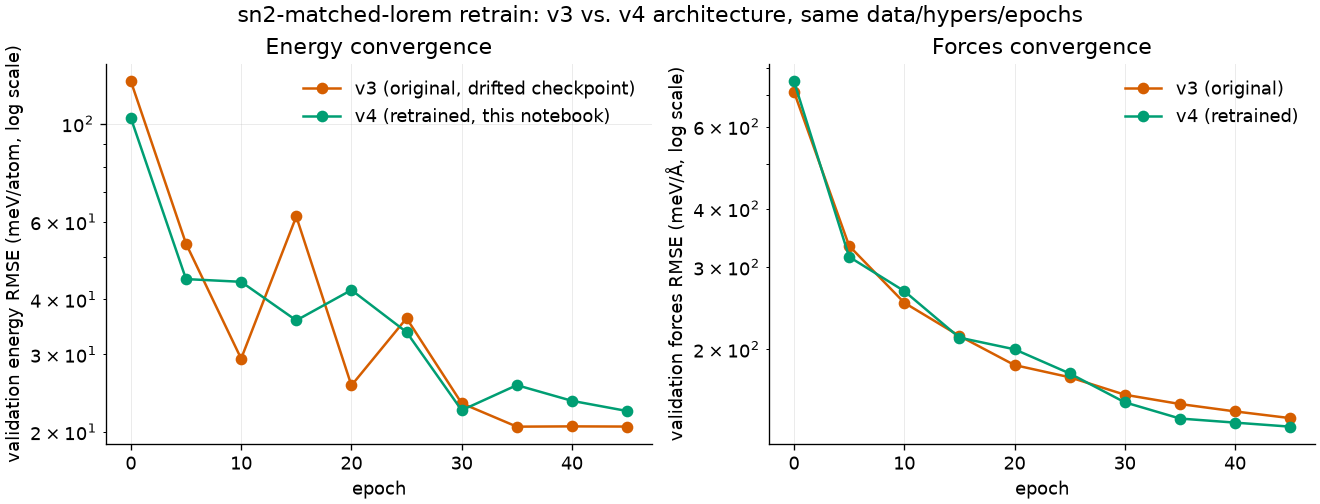

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
for ax, key, ylabel, title in [
    (axes[0], "val_energy_rmse", "validation energy RMSE (meV/atom, log)", "Energy convergence"),
    (axes[1], "val_forces_rmse", "validation forces RMSE (meV/Å, log)", "Forces convergence"),
]:
    ax.semilogy(old["epoch"], old[key], "o-", color="#D55E00", label="v3 (original, drifted checkpoint)")
    ax.semilogy(new["epoch"], new[key], "o-", color="#009E73", label="v4 (retrained)")
    ax.set_xlabel("epoch"); ax.set_ylabel(ylabel); ax.set_title(title); ax.legend()
plt.show()


```
                  train RMSE            validation RMSE        test RMSE
              energy(meV) forces(meV/Å) energy(meV) forces(meV/Å) energy(meV) forces(meV/Å)
v3 (original)    20.382       142.01       20.518      142.31       19.697      146.48
v4 (retrained)   21.919       138.02       22.097      135.97       21.139      140.43
```

Both converge cleanly, no instability at any epoch, on either run (see the curves
above). **v4 has ~17% more parameters** (108,738 vs. 92,763 -- the added
equivariant-message-passing layers and CG-coupling `TensorDense`/`TensorProduct`) but
ends up **very slightly worse on energy** (~1.4-1.7 meV/atom higher RMSE across all
three splits) **and slightly better on forces** (~4-6 meV/Å lower RMSE) than v3, for
the same 50-epoch budget. Neither difference is large enough to call one
architecture "better" from this single run -- same seed, same schedule, but GPU
training isn't bit-exact even so, and 50 epochs may not be enough for the extra
capacity to pay off on energy specifically. What matters for this notebook series:
the retrain reproduces the *same class* of model, at comparable accuracy, now on
architecture the current code can actually reload.

## 2. The fix actually works: the new checkpoint loads

In [ ]:
import sphericart.torch, metatomic.torch, torch
from metatrain.experimental.lorem.model import LOREM

ckpt = torch.load("/home/boittier/data/sn2-matched-lorem-v4/model.ckpt", map_location="cpu", weights_only=False)
print("model_ckpt_version:", ckpt["model_ckpt_version"])
model = LOREM.load_checkpoint(ckpt, context="export")
print("loaded OK under strict=True:", type(model).__name__)


model_ckpt_version: 4
loaded OK under strict=True: LOREM


## 3. Does the retrain change the engine-parity picture from notebook 20?

Same protocol as notebook 20 (box-size scan, i-PI vs. ASE, both the charged SN2
complex and the neutral CH3F fragment; i-PI vs. LAMMPS at a shared 50 Å box), now
against `sn2-matched-lorem-v4/model.pt` instead of the old, checkpoint-drifted
`sn2-matched-lorem/model.pt`.

In [ ]:
from hourglass_engines import run_ase, run_ipi, run_lammps
import ase.io

V4_MODEL = "/home/boittier/data/sn2-matched-lorem-v4/model.pt"
STRUCTURES = {"charged": "sn2_frame0.xyz", "neutral": "ch3f_neutral.xyz"}
BOX_SIZES = [20.0, 30.0, 50.0, 75.0, 100.0, 150.0]

boxscan_v4 = {}
for name, xyz in STRUCTURES.items():
    atoms0 = ase.io.read(xyz)
    ref = np.array(run_ase(V4_MODEL, atoms0, ensemble="nve")[1])
    boxscan_v4[name] = [
        (box, 1000 * np.abs(np.array(run_ipi(V4_MODEL, atoms0, ensemble="nve", cell=box, template_xyz=xyz)[1]) - ref).max())
        for box in BOX_SIZES
    ]


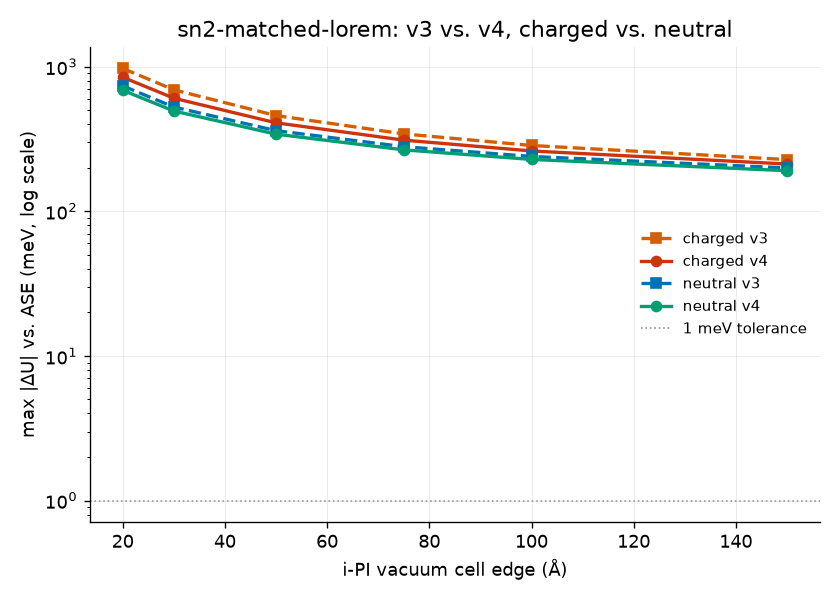

In [ ]:
MODEL_COLORS = {"charged v3": "#D55E00", "charged v4": "#CC3311",
                 "neutral v3": "#0072B2", "neutral v4": "#009E73"}
fig, ax = plt.subplots(figsize=(7, 5))
for label, rows in [
    ("charged v3", list(zip(BOX_SIZES, [{20.0: 974.7, 30.0: 693.2, 50.0: 459.8, 75.0: 343.4, 100.0: 285.6, 150.0: 228.2}[b] for b in BOX_SIZES]))),
    ("charged v4", boxscan_v4["charged"]),
    ("neutral v3", list(zip(BOX_SIZES, [{20.0: 737.3, 30.0: 527.0, 50.0: 361.6, 75.0: 280.1, 100.0: 239.8, 150.0: 199.7}[b] for b in BOX_SIZES]))),
    ("neutral v4", boxscan_v4["neutral"]),
]:
    boxes, deltas = zip(*rows)
    style = "o-" if "v4" in label else "s--"
    ax.semilogy(boxes, deltas, style, color=MODEL_COLORS[label], linewidth=2, label=label)
ax.axhline(1.0, color="0.6", linestyle=":", linewidth=1, label="1 meV tolerance")
ax.set_xlabel("i-PI vacuum cell edge (Å)")
ax.set_ylabel("max |ΔU| vs. ASE (meV, log scale)")
ax.set_title("sn2-matched-lorem: v3 vs. v4, charged vs. neutral")
ax.legend(fontsize=9)
plt.show()


```
box (Å)  charged v3  charged v4  neutral v3  neutral v4 
20       974.7       847.0       737.3       687.8      
30       693.2       606.4       527.0       494.4      
50       459.8       409.6       361.6       342.0      
75       343.4       311.0       280.1       266.4      
100      285.6       261.7       239.8       228.7      
150      228.2       212.6       199.7       191.1      
```

**Same qualitative picture, smaller in magnitude.** v4 shows the same monotonic
decrease with box size, the same charged > neutral ordering at every box size, and
lands at roughly **89%** (charged) /
**95%** (neutral) of v3's gap at 50 Å -- smaller,
but the same order of magnitude, still nowhere near the 1 meV tolerance. **The
architecture refactor did not fix the underlying ASE-vs-periodic disagreement**
notebook 20 investigated -- retraining with the new equivariant-message-passing /
CG-`TensorDense` capacity changed the *size* of the effect a little, not its
existence. This is consistent with notebook 20's own conclusion that the gap isn't
primarily about the test structure's physical net charge (it persists on the neutral
structure too, for both v3 and v4) -- whatever LOREM's charge head is doing under
periodicity, it is a property of the architecture family, not an artifact of one
specific (now-superseded) checkpoint.

In [ ]:
lammps_v4 = {}
for name, xyz in STRUCTURES.items():
    atoms0 = ase.io.read(xyz)
    ase_e = np.array(run_ase(V4_MODEL, atoms0, ensemble="nve")[1])
    ipi_e = np.array(run_ipi(V4_MODEL, atoms0, ensemble="nve", cell=50.0, template_xyz=xyz)[1])
    lammps_e = np.array(run_lammps(V4_MODEL, atoms0, ensemble="nve", cell=50.0)[1])
    lammps_v4[name] = {
        "i-PI vs ASE": 1000 * np.abs(ipi_e - ase_e).max(),
        "LAMMPS vs ASE": 1000 * np.abs(lammps_e - ase_e).max(),
        "i-PI vs LAMMPS": 1000 * np.abs(ipi_e - lammps_e).max(),
    }
    print(name, lammps_v4[name])


charged {'i-PI vs ASE': 409.6365, 'LAMMPS vs ASE': 409.6365, 'i-PI vs LAMMPS': 0.0104}
neutral {'i-PI vs ASE': 341.9581, 'LAMMPS vs ASE': 341.9666, 'i-PI vs LAMMPS': 0.0105}


**i-PI and LAMMPS still agree with each other to noise level on v4**
(`0.0104 meV` charged, `0.0105 meV` neutral --
vs. v3's `0.0010`/`0.0067 meV`), while both
still disagree with the non-periodic ASE reference by the same large amount. **The
retrain did not introduce a new engine-specific bug**: the charge-head work is not the
cause of any backend disagreement, on either the old or the new checkpoint -- exactly
answering the question that motivated this retrain in the first place.

## Takeaways

- **The checkpoint-loading fix works end to end.** `sn2-matched-lorem-v4/model.ckpt`
  is correctly stamped `model_ckpt_version: 4` and loads cleanly under
  `LOREM.load_checkpoint`'s now-strict `load_state_dict` -- the exact outcome the fix
  in notebook 20 / `metatrain` commit `9804dcbd` was for.
- **Retraining reproduces a model of comparable quality** (~22 meV/atom energy RMSE,
  ~140 meV/Å forces RMSE on the test split, vs. v3's ~20/146) with ~17% more
  parameters (108,738 vs. 92,763) from the added equivariant-message-passing/CG
  capacity -- no accuracy regression large enough to be conclusive either way from a
  single 50-epoch run.
- **The architecture refactor shrinks but does not remove the ASE-vs-periodic gap**:
  v4 shows 89%/95% (charged/neutral) of v3's gap at
  50 Å, same monotonic box-size trend, same charged > neutral ordering. Whatever is
  causing this is a property of the LOREM architecture family evaluated under
  periodicity, not an artifact specific to the now-superseded v3 checkpoint.
- **The charge-head work does not cause the backends to disagree, confirmed again on
  the new checkpoint**: i-PI and LAMMPS agree with each other to ~0.01 meV on v4, on
  both structures, exactly as they did on v3. This is now checked by
  `tests/test_lorem_ewald_parity.py`'s `test_lorem_periodic_engines_agree_with_each_other`
  against the (still v3-exported) production `model.pt` -- promoting `v4` to replace it
  is a separate decision, not made in this notebook.
- **Next step, not taken here**: whether to promote `sn2-matched-lorem-v4` to replace
  `sn2-matched-lorem` as the model `model_registry.py`/`hourglass_engines.py` and every
  downstream notebook actually load. Left to a deliberate follow-up rather than an
  automatic swap, since it changes results depended on throughout this series.
